# Ablation Experiments: Capacity and Sequence Length

**Purpose:** Address two key open questions from Experiment 1:
1. **A1: d_model sweep** — Is the flat dimensionality (~6-7) a capacity bottleneck?
2. **A2: seq_len sweep** — Does longer context allow K=8 to fully identify components?

**Setup:** Single seed (seed 0), K=4 for capacity sweep, all K for seq_len sweep.

In [4]:
# !pip install -U "numpy>=2.0" "scipy>=1.13" "scikit-learn>=1.5" transformer_lens einops transformers==4.37.2

import torch
import numpy as np
print(f"PyTorch: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    DEVICE = "cuda"
else:
    DEVICE = "cpu"
    print("WARNING: No GPU.")

PyTorch: 2.10.0+cu128
CUDA available: True
GPU: NVIDIA GeForce RTX 5090


In [5]:
import numpy as np
import torch
import torch.nn.functional as F
from typing import List, Tuple
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.metrics import accuracy_score
import warnings
warnings.filterwarnings("ignore")

class Mess3Process:
    def __init__(self, p: float):
        self.p = p
        self.transition_matrix = self._build_transition_matrix(p)
        self.stationary_dist = np.array([1/3, 1/3, 1/3])

    @staticmethod
    def _build_transition_matrix(p: float) -> np.ndarray:
        T = np.full((3, 3), p / 2)
        np.fill_diagonal(T, 1 - p)
        return T

    def generate_sequence(self, length: int) -> Tuple[List[int], List[int]]:
        state = np.random.choice(3, p=self.stationary_dist)
        states, tokens = [], []
        for _ in range(length):
            states.append(state)
            tokens.append(state)
            state = np.random.choice(3, p=self.transition_matrix[state])
        return tokens, states


class NonErgodicDataset:
    def __init__(self, p_values: List[float], seq_len: int = 16):
        self.processes = [Mess3Process(p) for p in p_values]
        self.p_values = p_values
        self.K = len(p_values)
        self.seq_len = seq_len

    def sample_batch(self, batch_size: int) -> Tuple[torch.Tensor, torch.Tensor]:
        all_tokens, comp_ids = [], []
        for _ in range(batch_size):
            k = np.random.randint(self.K)
            toks, _ = self.processes[k].generate_sequence(self.seq_len)
            shifted = [t + 1 for t in toks]
            all_tokens.append([0] + shifted)
            comp_ids.append(k)
        return (torch.tensor(all_tokens, dtype=torch.long),
                torch.tensor(comp_ids, dtype=torch.long))


def compute_component_posterior(tokens, p_values, bos_token=0):
    batch_size, seq_len = tokens.shape
    K = len(p_values)
    processes = [Mess3Process(p) for p in p_values]
    posterior = torch.zeros(batch_size, seq_len, K)
    for b in range(batch_size):
        log_prior = np.log(np.ones(K) / K)
        beliefs = [np.array([1/3, 1/3, 1/3]) for _ in range(K)]
        for t in range(seq_len):
            tok = tokens[b, t].item()
            if tok == bos_token:
                log_post = log_prior.copy()
            else:
                observed_state = tok - 1
                for ki in range(K):
                    log_prior[ki] += np.log(beliefs[ki][observed_state] + 1e-30)
                    beliefs[ki] = processes[ki].transition_matrix[observed_state]
                log_post = log_prior.copy()
            log_post_shifted = log_post - np.max(log_post)
            post = np.exp(log_post_shifted)
            post /= post.sum()
            posterior[b, t] = torch.tensor(post)
    return posterior


print("Data generation code loaded.")

Data generation code loaded.


In [7]:
from transformer_lens import HookedTransformer, HookedTransformerConfig

def create_model(n_layers=2, d_model=64, d_mlp=None, n_heads=4, n_ctx=17, d_vocab=4, device="gpu"):
    if d_mlp is None:
        d_mlp = 4 * d_model
    d_head = d_model // n_heads
    cfg = HookedTransformerConfig(
        n_layers=n_layers, d_model=d_model, d_head=d_head,
        d_mlp=d_mlp, n_heads=n_heads, n_ctx=n_ctx, d_vocab=d_vocab,
        act_fn="gelu", normalization_type="LN",
    )
    return HookedTransformer(cfg).to(device)

def train_step(model, optimizer, tokens):
    model.train()
    logits = model(tokens[:, :-1])
    targets = tokens[:, 1:]
    loss = F.cross_entropy(logits.reshape(-1, logits.shape[-1]), targets.reshape(-1))
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    return loss.item()

def extract_activations(model, tokens):
    model.eval()
    with torch.no_grad():
        _, cache = model.run_with_cache(tokens)
    activations = {}
    activations["embed"] = cache["hook_embed"]
    if "hook_pos_embed" in cache:
        activations["embed"] = activations["embed"] + cache["hook_pos_embed"]
    for i in range(model.cfg.n_layers):
        activations[f"layer{i}"] = cache[f"blocks.{i}.hook_resid_post"]
    activations["final"] = activations[f"layer{model.cfg.n_layers - 1}"]
    return activations

print("Model code loaded.")

Model code loaded.


## A1: d_model Capacity Sweep

**Question:** Is the flat dimensionality (~6-7 regardless of K) due to a capacity bottleneck at d_model=64?

**Method:** Train K=4 with d_model in {32, 64, 128, 256}. Also test K=8 with d_model in {64, 128, 256}.

In [8]:
CAPACITY_CONFIGS = [
    (32,  2, 4, [0.1, 0.3, 0.7, 0.9], "K4_d32"),
    (64,  4, 4, [0.1, 0.3, 0.7, 0.9], "K4_d64"),
    (128, 4, 4, [0.1, 0.3, 0.7, 0.9], "K4_d128"),
    (256, 4, 4, [0.1, 0.3, 0.7, 0.9], "K4_d256"),
    (64,  4, 8, [0.1, 0.2, 0.3, 0.4, 0.6, 0.7, 0.8, 0.9], "K8_d64"),
    (128, 4, 8, [0.1, 0.2, 0.3, 0.4, 0.6, 0.7, 0.8, 0.9], "K8_d128"),
    (256, 4, 8, [0.1, 0.2, 0.3, 0.4, 0.6, 0.7, 0.8, 0.9], "K8_d256"),
]

SEQ_LEN = 16
N_STEPS = 10_000
BATCH_SIZE = 256
LR = 1e-3
N_TEST = 5000

a1_results = {}

for d_model, n_heads, K, p_values, label in CAPACITY_CONFIGS:
    print(f"\n{'='*60}")
    print(f"Training {label}: d_model={d_model}, K={K}")
    print(f"{'='*60}")

    torch.manual_seed(0)
    np.random.seed(0)

    dataset = NonErgodicDataset(p_values=p_values, seq_len=SEQ_LEN)
    model = create_model(
        n_layers=2, d_model=d_model, n_heads=n_heads,
        n_ctx=SEQ_LEN + 1, d_vocab=4, device=DEVICE,
    )
    n_params = sum(p.numel() for p in model.parameters())
    print(f"  Parameters: {n_params:,}")

    optimizer = torch.optim.Adam(model.parameters(), lr=LR)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=N_STEPS)

    losses = []
    for step in range(N_STEPS):
        tokens, comp_ids = dataset.sample_batch(BATCH_SIZE)
        tokens = tokens.to(DEVICE)
        loss = train_step(model, optimizer, tokens)
        scheduler.step()
        losses.append(loss)
        if step % 2000 == 0:
            print(f"  Step {step:5d}/{N_STEPS} | Loss: {loss:.4f}")

    torch.manual_seed(999)
    np.random.seed(999)
    test_tokens, test_comp_ids = dataset.sample_batch(N_TEST)

    all_acts = []
    batch_sz = 500
    for start in range(0, N_TEST, batch_sz):
        end = min(start + batch_sz, N_TEST)
        acts = extract_activations(model, test_tokens[start:end].to(DEVICE))
        all_acts.append(acts["final"].cpu())
    final_acts = torch.cat(all_acts, dim=0)

    # All positions
    acts_flat = final_acts.reshape(-1, d_model).numpy()
    pca_obj = PCA()
    pca_obj.fit(acts_flat)
    cev_all = np.cumsum(pca_obj.explained_variance_ratio_)
    eff_dim_all = np.searchsorted(cev_all, 0.95) + 1

    # Late positions only
    late_acts = final_acts[:, 8:, :].reshape(-1, d_model).numpy()
    pca_late = PCA()
    pca_late.fit(late_acts)
    cev_late = np.cumsum(pca_late.explained_variance_ratio_)
    eff_dim_late = np.searchsorted(cev_late, 0.95) + 1
    evals_late = pca_late.explained_variance_
    pr_late = (evals_late.sum() ** 2) / (evals_late ** 2).sum()

    # Single position
    acts_12 = final_acts[:, 12, :].numpy()
    pca_12 = PCA()
    pca_12.fit(acts_12)
    cev_12 = np.cumsum(pca_12.explained_variance_ratio_)
    eff_dim_12 = np.searchsorted(cev_12, 0.95) + 1

    final_loss = np.mean(losses[-100:])
    a1_results[label] = {
        "d_model": d_model, "K": K, "n_params": n_params,
        "final_loss": final_loss,
        "eff_dim_all": eff_dim_all, "eff_dim_late": eff_dim_late,
        "eff_dim_pos12": eff_dim_12,
        "pr_late": pr_late,
        "cev_late": cev_late,
    }

    print(f"  Final loss: {final_loss:.4f}")
    print(f"  Eff dim (all): {eff_dim_all}, (late): {eff_dim_late}, (pos12): {eff_dim_12}")
    print(f"  Part. ratio (late): {pr_late:.1f}")

    del model, optimizer, scheduler
    torch.cuda.empty_cache() if DEVICE == "cuda" else None

print("\nA1 training complete!")


Training K4_d32: d_model=32, K=4
Moving model to device:  cuda
  Parameters: 26,276
  Step     0/10000 | Loss: 2.3936
  Step  2000/10000 | Loss: 0.8873
  Step  4000/10000 | Loss: 0.8725
  Step  6000/10000 | Loss: 0.8950
  Step  8000/10000 | Loss: 0.9097
  Final loss: 0.8899
  Eff dim (all): 9, (late): 7, (pos12): 6
  Part. ratio (late): 5.2

Training K4_d64: d_model=64, K=4
Moving model to device:  cuda
  Parameters: 101,700
  Step     0/10000 | Loss: 1.4628
  Step  2000/10000 | Loss: 0.8883
  Step  4000/10000 | Loss: 0.8720
  Step  6000/10000 | Loss: 0.8943
  Step  8000/10000 | Loss: 0.9093
  Final loss: 0.8897
  Eff dim (all): 7, (late): 6, (pos12): 6
  Part. ratio (late): 4.5

Training K4_d128: d_model=128, K=4
Moving model to device:  cuda
  Parameters: 400,004
  Step     0/10000 | Loss: 1.4587
  Step  2000/10000 | Loss: 0.8883
  Step  4000/10000 | Loss: 0.8727
  Step  6000/10000 | Loss: 0.8944
  Step  8000/10000 | Loss: 0.9092
  Final loss: 0.8897
  Eff dim (all): 7, (late): 6, (

A1: CAPACITY SWEEP RESULTS

Label         d_model    K     Params     Loss  d_all  d_late  d_pos12  PR_late   Pred
------------------------------------------------------------------------------------------
K4_d32             32    4     26,276   0.8899      9       7        6      5.2      5
K4_d64             64    4    101,700   0.8897      7       6        6      4.5      5
K4_d128           128    4    400,004   0.8897      7       6        6      4.3      5
K4_d256           256    4  1,586,436   0.8897      9       7        7      4.2      5
K8_d64             64    8    101,700   0.9438      7       6        6      4.7      9
K8_d128           128    8    400,004   0.9438      8       7        7      4.3      9
K8_d256           256    8  1,586,436   0.9438      8       7        7      4.6      9


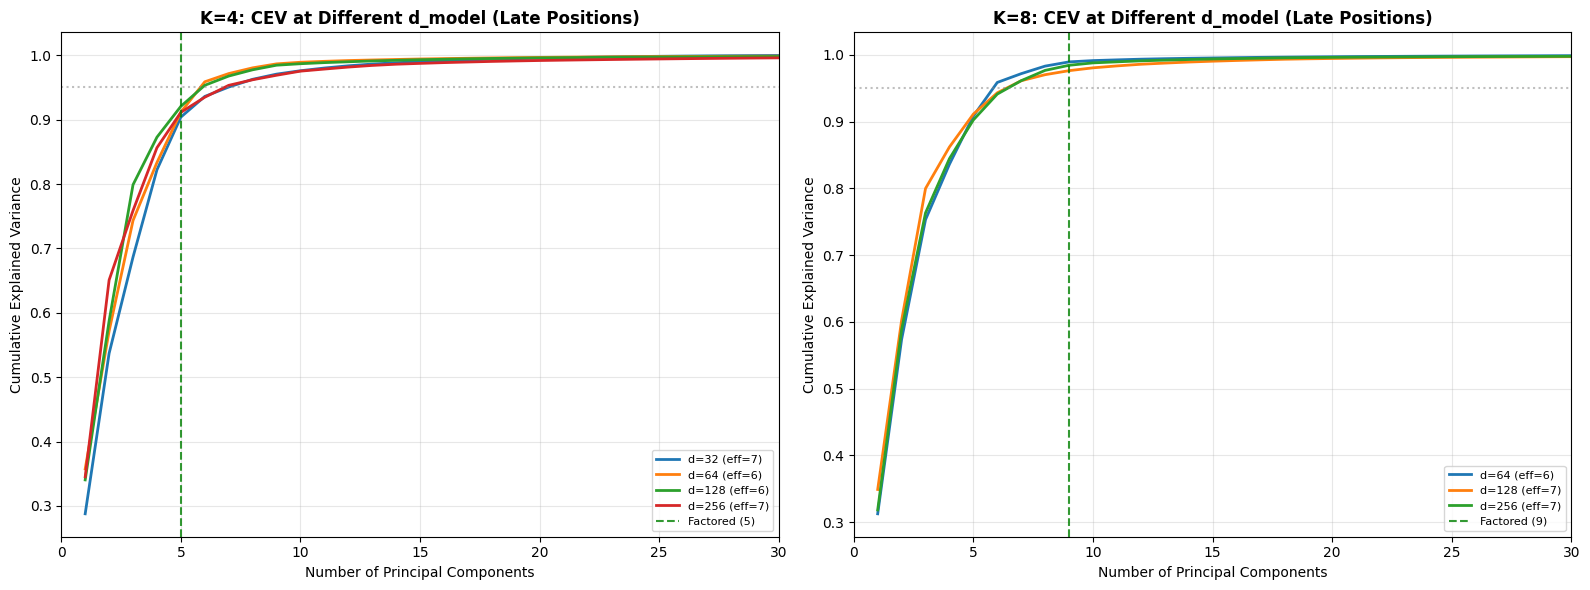

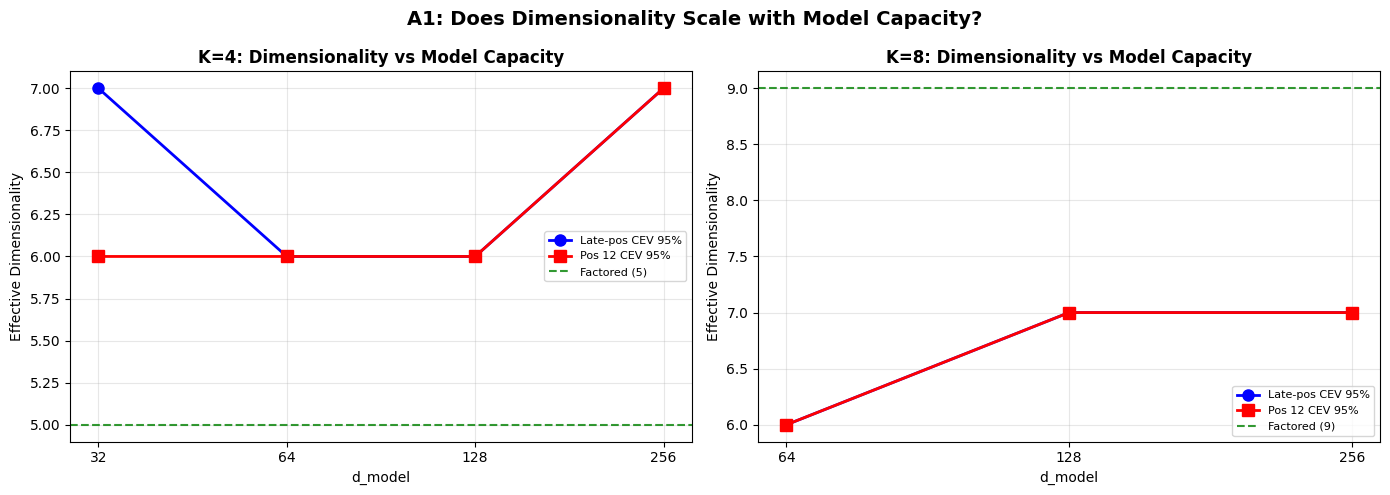


Saved: fig_a1_capacity_cev.pdf, fig_a1_capacity_scaling.pdf

--- INTERPRETATION ---
If dims INCREASE with d_model -> capacity bottleneck
If dims STAY FLAT -> real representation property


In [9]:
print("=" * 70)
print("A1: CAPACITY SWEEP RESULTS")
print("=" * 70)

print(f"\n{'Label':<12} {'d_model':>8} {'K':>4} {'Params':>10} {'Loss':>8} {'d_all':>6} {'d_late':>7} {'d_pos12':>8} {'PR_late':>8} {'Pred':>6}")
print("-" * 90)
for label, r in a1_results.items():
    print(f"{label:<12} {r['d_model']:>8} {r['K']:>4} {r['n_params']:>10,} {r['final_loss']:>8.4f} "
          f"{r['eff_dim_all']:>6} {r['eff_dim_late']:>7} {r['eff_dim_pos12']:>8} {r['pr_late']:>8.1f} {r['K']+1:>6}")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

ax = axes[0]
for label, r in a1_results.items():
    if r["K"] == 4:
        n = min(40, len(r['cev_late']))
        ax.plot(range(1, n+1), r['cev_late'][:n],
                linewidth=2, label=f"d={r['d_model']} (eff={r['eff_dim_late']})")
ax.axvline(5, color="green", linestyle="--", alpha=0.8, label="Factored (5)")
ax.axhline(0.95, color="gray", linestyle=":", alpha=0.5)
ax.set_title("K=4: CEV at Different d_model (Late Positions)", fontweight="bold")
ax.set_xlabel("Number of Principal Components")
ax.set_ylabel("Cumulative Explained Variance")
ax.legend(fontsize=8)
ax.set_xlim(0, 30)
ax.grid(True, alpha=0.3)

ax = axes[1]
for label, r in a1_results.items():
    if r["K"] == 8:
        n = min(40, len(r['cev_late']))
        ax.plot(range(1, n+1), r['cev_late'][:n],
                linewidth=2, label=f"d={r['d_model']} (eff={r['eff_dim_late']})")
ax.axvline(9, color="green", linestyle="--", alpha=0.8, label="Factored (9)")
ax.axhline(0.95, color="gray", linestyle=":", alpha=0.5)
ax.set_title("K=8: CEV at Different d_model (Late Positions)", fontweight="bold")
ax.set_xlabel("Number of Principal Components")
ax.set_ylabel("Cumulative Explained Variance")
ax.legend(fontsize=8)
ax.set_xlim(0, 30)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("fig_a1_capacity_cev.pdf", dpi=150, bbox_inches="tight")
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for plot_K, ax in [(4, axes[0]), (8, axes[1])]:
    d_models, dims_late, dims_pos12 = [], [], []
    for label, r in a1_results.items():
        if r["K"] == plot_K:
            d_models.append(r["d_model"])
            dims_late.append(r["eff_dim_late"])
            dims_pos12.append(r["eff_dim_pos12"])
    ax.plot(d_models, dims_late, "o-", linewidth=2, markersize=8, label="Late-pos CEV 95%", color="blue")
    ax.plot(d_models, dims_pos12, "s-", linewidth=2, markersize=8, label="Pos 12 CEV 95%", color="red")
    ax.axhline(plot_K + 1, color="green", linestyle="--", alpha=0.8, label=f"Factored ({plot_K+1})")
    ax.set_title(f"K={plot_K}: Dimensionality vs Model Capacity", fontweight="bold")
    ax.set_xlabel("d_model")
    ax.set_ylabel("Effective Dimensionality")
    ax.legend(fontsize=8)
    ax.set_xscale("log", base=2)
    ax.set_xticks(d_models)
    ax.get_xaxis().set_major_formatter(plt.ScalarFormatter())
    ax.grid(True, alpha=0.3)

plt.suptitle("A1: Does Dimensionality Scale with Model Capacity?", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("fig_a1_capacity_scaling.pdf", dpi=150, bbox_inches="tight")
plt.show()

print("\nSaved: fig_a1_capacity_cev.pdf, fig_a1_capacity_scaling.pdf")
print("\n--- INTERPRETATION ---")
print("If dims INCREASE with d_model -> capacity bottleneck")
print("If dims STAY FLAT -> real representation property")

## A2: Sequence Length Sweep

**Question:** Does longer context allow K=8 to fully identify components and change dimensionality?

**Method:** Train K=2,4,8 with seq_len in {32, 64}. Compare with Experiment 1 baselines (seq_len=16).

In [ ]:
SEQLEN_CONFIGS = [
    (32,  2, [0.1, 0.9], "K2_seq32"),
    (64,  2, [0.1, 0.9], "K2_seq64"),
    (32,  4, [0.1, 0.3, 0.7, 0.9], "K4_seq32"),
    (64,  4, [0.1, 0.3, 0.7, 0.9], "K4_seq64"),
    (32,  8, [0.1, 0.2, 0.3, 0.4, 0.6, 0.7, 0.8, 0.9], "K8_seq32"),
    (64,  8, [0.1, 0.2, 0.3, 0.4, 0.6, 0.7, 0.8, 0.9], "K8_seq64"),
]
print("hello")
D_MODEL = 64
N_HEADS = 4
N_STEPS = 10_000
BATCH_SIZE = 256
LR = 1e-3
N_TEST = 5000

a2_results = {}

for seq_len, K, p_values, label in SEQLEN_CONFIGS:
    print(f"\n{'='*60}")
    print(f"Training {label}: seq_len={seq_len}, K={K}")
    print(f"{'='*60}")

    torch.manual_seed(0)
    np.random.seed(0)

    dataset = NonErgodicDataset(p_values=p_values, seq_len=seq_len)
    model = create_model(
        n_layers=2, d_model=D_MODEL, n_heads=N_HEADS,
        n_ctx=seq_len + 1, d_vocab=4, device=DEVICE,
    )

    optimizer = torch.optim.Adam(model.parameters(), lr=LR)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=N_STEPS)

    losses = []
    for step in range(N_STEPS):
        tokens, comp_ids = dataset.sample_batch(BATCH_SIZE)
        tokens = tokens.to(DEVICE)
        loss = train_step(model, optimizer, tokens)
        scheduler.step()
        losses.append(loss)
        if step % 2000 == 0:
            print(f"  Step {step:5d}/{N_STEPS} | Loss: {loss:.4f}")

    torch.manual_seed(999)
    np.random.seed(999)
    test_tokens, test_comp_ids = dataset.sample_batch(N_TEST)

    all_acts = []
    batch_sz = 500
    for start in range(0, N_TEST, batch_sz):
        end = min(start + batch_sz, N_TEST)
        acts = extract_activations(model, test_tokens[start:end].to(DEVICE))
        all_acts.append(acts["final"].cpu())
    final_acts = torch.cat(all_acts, dim=0)

    # Component ID accuracy at each position
    comp_ids_np = test_comp_ids.numpy()
    n_train = int(N_TEST * 0.8)
    positions = list(range(1, seq_len + 1))
    probe_accs = []
    for t in positions:
        acts_t = final_acts[:, t, :].numpy()
        clf = LogisticRegression(max_iter=1000, random_state=0, C=1.0)
        clf.fit(acts_t[:n_train], comp_ids_np[:n_train])
        acc = accuracy_score(comp_ids_np[n_train:], clf.predict(acts_t[n_train:]))
        probe_accs.append(acc)

    # Dimensionality (late half)
    half = seq_len // 2
    late_acts = final_acts[:, half:, :].reshape(-1, D_MODEL).numpy()
    pca_obj = PCA()
    pca_obj.fit(late_acts)
    cev = np.cumsum(pca_obj.explained_variance_ratio_)
    eff_dim = np.searchsorted(cev, 0.95) + 1
    evals = pca_obj.explained_variance_
    pr = (evals.sum() ** 2) / (evals ** 2).sum()

    final_loss = np.mean(losses[-100:])
    a2_results[label] = {
        "seq_len": seq_len, "K": K, "final_loss": final_loss,
        "eff_dim": eff_dim, "part_ratio": pr,
        "probe_accs": probe_accs, "positions": positions,
        "max_acc": max(probe_accs), "final_acc": probe_accs[-1],
    }

    print(f"  Final loss: {final_loss:.4f}")
    print(f"  Late-half eff dim: {eff_dim}, PR: {pr:.1f}")
    print(f"  Component ID at final pos: {probe_accs[-1]:.3f}")

    del model, optimizer, scheduler
    torch.cuda.empty_cache() if DEVICE == "cuda" else None

print("\nA2 training complete!")

In [ ]:
print("=" * 70)
print("A2: SEQUENCE LENGTH SWEEP RESULTS")
print("=" * 70)

print(f"\n{'Label':<12} {'seq_len':>8} {'K':>4} {'Loss':>8} {'d_late':>7} {'PR':>6} {'Final Acc':>10} {'Pred d':>8}")
print("-" * 70)
for label, r in a2_results.items():
    print(f"{label:<12} {r['seq_len']:>8} {r['K']:>4} {r['final_loss']:>8.4f} "
          f"{r['eff_dim']:>7} {r['part_ratio']:>6.1f} {r['final_acc']:>10.3f} {r['K']+1:>8}")

baseline_results = {
    "K2_seq16": {"seq_len": 16, "K": 2, "final_acc": 1.000, "eff_dim": 6},
    "K4_seq16": {"seq_len": 16, "K": 4, "final_acc": 0.818, "eff_dim": 7},
    "K8_seq16": {"seq_len": 16, "K": 8, "final_acc": 0.472, "eff_dim": 7},
}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for plot_K, ax in [(2, axes[0]), (4, axes[1]), (8, axes[2])]:
    for label, r in a2_results.items():
        if r["K"] == plot_K:
            ax.plot(r["positions"], r["probe_accs"], "o-", linewidth=2, markersize=3,
                    label=f"seq={r['seq_len']}")
    ax.axhline(1.0/plot_K, color="gray", linestyle=":", alpha=0.5, label=f"Chance ({1/plot_K:.2f})")
    ax.set_title(f"K={plot_K}: Component ID vs Position")
    ax.set_xlabel("Context Position")
    ax.set_ylabel("Accuracy")
    ax.set_ylim(0, 1.05)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle("A2: Component Identification with Longer Sequences", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("fig_a2_seqlen_component_id.pdf", dpi=150, bbox_inches="tight")
plt.show()

fig, ax = plt.subplots(figsize=(10, 6))
for plot_K in [2, 4, 8]:
    seq_lens, dims = [], []
    base_key = f"K{plot_K}_seq16"
    if base_key in baseline_results:
        seq_lens.append(16)
        dims.append(baseline_results[base_key]["eff_dim"])
    for label, r in a2_results.items():
        if r["K"] == plot_K:
            seq_lens.append(r["seq_len"])
            dims.append(r["eff_dim"])
    ax.plot(seq_lens, dims, "o-", linewidth=2, markersize=8, label=f"K={plot_K} (pred={plot_K+1})")

ax.set_xlabel("Sequence Length", fontsize=12)
ax.set_ylabel("Effective Dimensionality (late-half, 95% CEV)", fontsize=12)
ax.set_title("A2: Does Sequence Length Affect Dimensionality?", fontsize=14, fontweight="bold")
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("fig_a2_seqlen_dim.pdf", dpi=150, bbox_inches="tight")
plt.show()

fig, ax = plt.subplots(figsize=(10, 6))
for plot_K in [2, 4, 8]:
    seq_lens, accs = [], []
    base_key = f"K{plot_K}_seq16"
    if base_key in baseline_results:
        seq_lens.append(16)
        accs.append(baseline_results[base_key]["final_acc"])
    for label, r in a2_results.items():
        if r["K"] == plot_K:
            seq_lens.append(r["seq_len"])
            accs.append(r["final_acc"])
    ax.plot(seq_lens, accs, "o-", linewidth=2, markersize=8, label=f"K={plot_K}")

ax.set_xlabel("Sequence Length", fontsize=12)
ax.set_ylabel("Final Position Component ID Accuracy", fontsize=12)
ax.set_title("A2: Does Longer Context Improve Component Identification?", fontsize=14, fontweight="bold")
ax.legend(fontsize=10)
ax.set_ylim(0, 1.05)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("fig_a2_seqlen_acc.pdf", dpi=150, bbox_inches="tight")
plt.show()

print("\nSaved: fig_a2_seqlen_component_id.pdf, fig_a2_seqlen_dim.pdf, fig_a2_seqlen_acc.pdf")

In [ ]:
import glob

print("=" * 70)
print("ABLATION EXPERIMENTS COMPLETE")
print("=" * 70)

print("\n--- A1: Capacity Sweep ---")
for label, r in a1_results.items():
    print(f"  {label}: d_model={r['d_model']}, K={r['K']}, "
          f"d_late={r['eff_dim_late']}, d_pos12={r['eff_dim_pos12']}, "
          f"pred={r['K']+1}")

print("\n--- A2: Sequence Length Sweep ---")
for label, r in a2_results.items():
    print(f"  {label}: seq_len={r['seq_len']}, K={r['K']}, "
          f"d_late={r['eff_dim']}, final_acc={r['final_acc']:.3f}, "
          f"pred_d={r['K']+1}")

print("\n--- Generated Figures ---")
for f in sorted(glob.glob("*.pdf")):
    print(f"  {f}")

print("\nDownload all PDFs and update docs/experiment_log.md")